In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
data = {
    "Area": [1000,1200,1500,1800,2000,2200,2500,2700,3000,3500],
    "Bedrooms": [2,2,3,3,4,4,4,5,5,6],
    "Age": [10,8,5,7,4,3,2,2,1,1],
    "Price": [200000,230000,300000,340000,400000,440000,500000,550000,600000,700000]
}

df = pd.DataFrame(data)

df.head()

,Area,Bedrooms,Age,Price
0,1000,2,10,200000
1,1200,2,8,230000
2,1500,3,5,300000
3,1800,3,7,340000
4,2000,4,4,400000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      10 non-null     int64
 1   Bedrooms  10 non-null     int64
 2   Age       10 non-null     int64
 3   Price     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [4]:
df.describe()

,Area,Bedrooms,Age,Price
count,10.00000,10.000000,10.00000,10.000000
mean,2140.00000,3.800000,4.30000,426000.000000
std,800.27773,1.316561,3.12872,163244.874005
min,1000.00000,2.000000,1.00000,200000.000000
25%,1575.00000,3.000000,2.00000,310000.000000
50%,2100.00000,4.000000,3.50000,420000.000000
75%,2650.00000,4.750000,6.50000,537500.000000
max,3500.00000,6.000000,10.00000,700000.000000


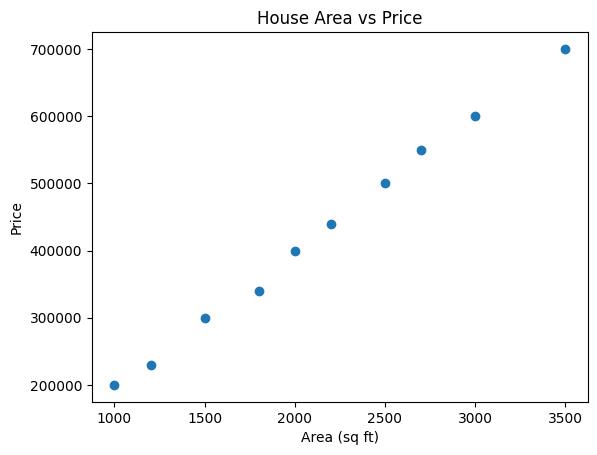

In [5]:
plt.scatter(df["Area"], df["Price"])

plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.title("House Area vs Price")

plt.show()

In [6]:
X = df[["Area", "Bedrooms", "Age"]]

y = df["Price"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
predictions = model.predict(X_test)

print(predictions)

[598524.43802846 229645.28768818]


In [10]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 915.1371416787151


In [11]:
new_house = [[2400, 4, 3]]

predicted_price = model.predict(new_house)

print("Predicted Price: $", round(predicted_price[0], 2))

Predicted Price: $ 476134.25


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']